# Book Recommendation Algorithm - Dataset Analysis

### Imports

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

ratings = pd.read_csv('archive/Ratings.csv', usecols=['User-ID', 'ISBN', 'Book-Rating'])
books = pd.read_csv('archive/Books.csv', usecols=['ISBN', 'Book-Title', 'Book-Author'])
users = pd.read_csv('archive/Users.csv', usecols=['User-ID', 'Location', 'Age'])
print("Ratings shape:", ratings.shape)
print("Books shape:", books.shape)
print("Users shape:", users.shape)

Ratings shape: (1149780, 3)
Books shape: (271360, 3)
Users shape: (278858, 3)


In [ ]:
df = pd.merge(ratings, books, on='ISBN')
print("Merged df shape:", df.shape)
df.head()

Merged df shape: (1031136, 5)


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose
1,276726,0155061224,5,Rites of Passage,Judith Rae
2,276727,0446520802,0,The Notebook,Nicholas Sparks
3,276729,052165615X,3,Help!: Level 1,Philip Prowse
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather


### Ratinings of books that are not in books.csv

In [ ]:
lost = len(ratings) - len(df)
print(f"Ratings: {len(ratings):,}")
print(f"Merged: {len(df):,}")
print(f"Lost: {lost:,} ({lost/len(ratings)*100:.2f}%)")

missing_in_books = ratings[~ratings['ISBN'].isin(books['ISBN'])]
print(f"\nRatings with ISBN not found in Books: {len(missing_in_books):,}")
non_zero_missing = (missing_in_books['Book-Rating'] != 0).sum()
zero_missing = (missing_in_books['Book-Rating'] == 0).sum()
non_zero_missing_pct = non_zero_missing / len(missing_in_books) * 100
print(f"Non-zero ratings among missing-ISBN records: {non_zero_missing:,} ({non_zero_missing_pct:.2f}%)")
print(f"Zero ratings among missing-ISBN records: {zero_missing:,}")


Ratings: 1,149,780
Merged: 1,031,136
Lost: 118,644 (10.32%)

Ratings with ISBN not found in Books: 118,644
Non-zero ratings among missing-ISBN records: 49,829 (42.00%)
Zero ratings among missing-ISBN records: 68,815


A part of rated books are not in the Book.csv file - we will not use them in this project

### Zero values

In [58]:

df_explicit = df[df['Book-Rating'] > 0]
original_count = len(df)
new_count = len(df_explicit)
removed_count = original_count - new_count

print(f"Original number of ratings: {original_count:,}")
print(f"Explicit ratings remaining: {new_count:,}")
print(f"Removed: {removed_count:,} ({removed_count / original_count * 100:.2f}%) zero ratings")
df_explicit.info()

df = df_explicit

Original number of ratings: 1,031,136
Explicit ratings remaining: 383,842
Removed: 647,294 (62.77%) zero ratings
<class 'pandas.DataFrame'>
Index: 383842 entries, 1 to 1031135
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   User-ID      383842 non-null  int64
 1   ISBN         383842 non-null  str  
 2   Book-Rating  383842 non-null  int64
 3   Book-Title   383842 non-null  str  
 4   Book-Author  383840 non-null  str  
dtypes: int64(2), str(3)
memory usage: 17.6 MB


In [ ]:
dup = df.duplicated().sum()
print(f"Duplicate rows: {dup:,}")
df.isnull().sum()

Duplicate rows: 0


User-ID        0
ISBN           0
Book-Rating    0
Book-Title     0
Book-Author    2
dtype: int64

### Users with only one rating

In [61]:
user_book_counts = df.groupby('User-ID')['ISBN'].nunique()
single_book_users = user_book_counts[user_book_counts == 1]

print(f"Users who rated only 1 book: {len(single_book_users):,}")
print(f"Percent of all users: {len(single_book_users) / df['User-ID'].nunique() * 100:.2f}%")

Users who rated only 1 book: 39,223
Percent of all users: 57.60%


Almost 58% of users rated just one book witch is useless for item-based collaborative filtering. It maight be a good solution to use a hybrid model with item/content-based filtering based on the amount of rating from one user.

### Activity distribution

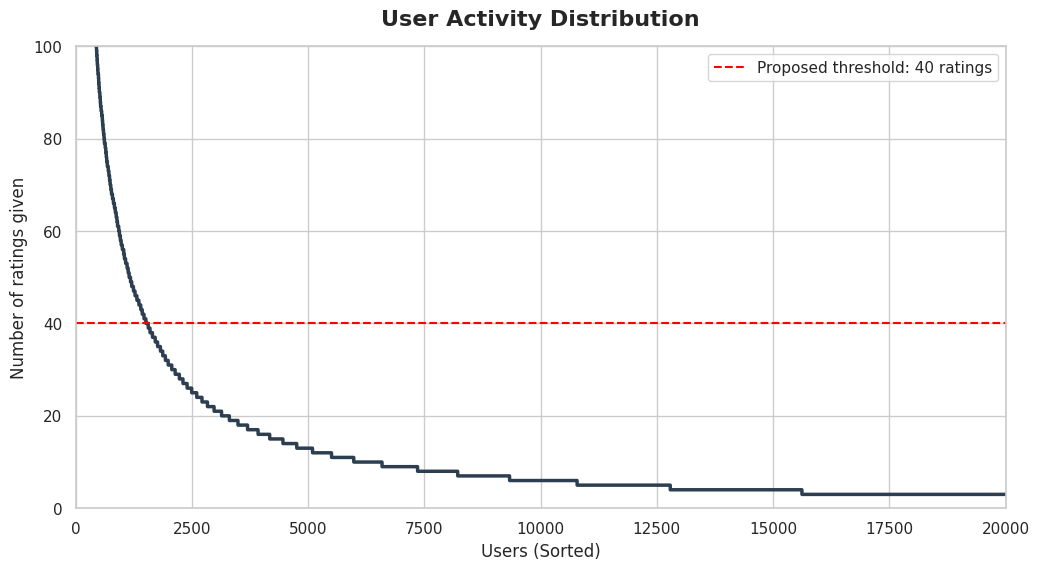

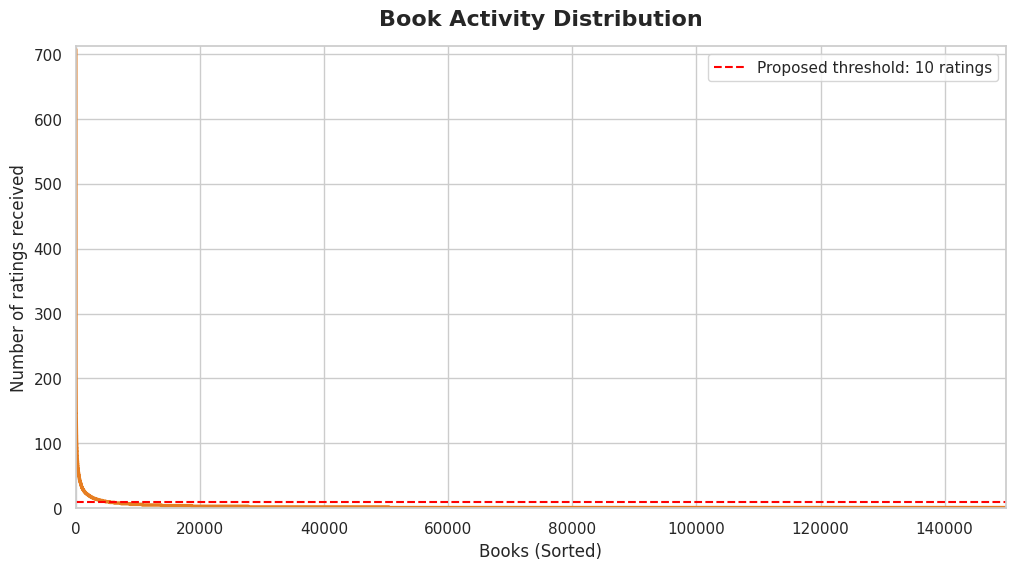

In [ ]:
sns.set_theme(style="whitegrid")

# User activity distribution
plt.figure(figsize=(12, 6))
user_ratings_count = df['User-ID'].value_counts().values
plt.plot(user_ratings_count, color='#2c3e50', linewidth=2.5)

plt.title('User Activity Distribution', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Users (Sorted)', fontsize=12)
plt.ylabel('Number of ratings given', fontsize=12)
plt.xlim(0, 20000)
plt.ylim(0, 100)

rating_threshold = 40
plt.axhline(y=rating_threshold, color='red', linestyle='--', label=f'Proposed threshold: {rating_threshold} ratings')
plt.legend()
plt.show()

# Book activity distribution
plt.figure(figsize=(12, 6))
book_ratings_count = df['ISBN'].value_counts().values
plt.plot(book_ratings_count, color='#e67e22', linewidth=2.5)

plt.title('Book Activity Distribution', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Books (Sorted)', fontsize=12)
plt.ylabel('Number of ratings received', fontsize=12)
plt.xlim(0, len(book_ratings_count) + 10)
plt.ylim(0, max(book_ratings_count.max(), 20) + 5)

book_threshold = 10
plt.axhline(y=book_threshold, color='red', linestyle='--', label=f'Proposed threshold: {book_threshold} ratings')
plt.legend()
plt.show()

### Item-based Collaborative Filtering 
Using only highly active users (>40 ratings) to reduce matrix size

In [90]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

user_counts = df.groupby("User-ID").size()
power_users = user_counts[user_counts > 40].index
df_power = df[df["User-ID"].isin(power_users)]

print(f"Power users (>40 ratings): {len(power_users):,}")
print(f"Total ratings from power users: {len(df_power):,}")

book_counts = df_power['ISBN'].value_counts()
books_with_ratings = book_counts[book_counts >= 10].index
df_filtered = df_power[df_power['ISBN'].isin(books_with_ratings)]

print(f"Books remaining for calculation: {len(books_with_ratings):,}")

item_user = df_filtered.pivot_table(
    index="ISBN",
    columns="User-ID",
    values="Book-Rating",
    aggfunc="mean"
).fillna(0).astype('float32')


# Calculate matrix sparsity
total_cells = item_user.shape[0] * item_user.shape[1]
zero_cells = (item_user == 0).sum().sum()
print(f"Matrix sparsity: {(zero_cells / total_cells) * 100:.1f}%")

# Conterting to csr matrix
print("Converting to sparse matrix...")
sparse_item_user = csr_matrix(item_user.values)

# Compute item-item similarity
print("Computing item similarity...")
item_sim_array = cosine_similarity(sparse_item_user)

item_sim = pd.DataFrame(
    item_sim_array,
    index=item_user.index,
    columns=item_user.index
)


def recommend_similar_books(book_isbn, top_n=5):
    if book_isbn not in item_sim.index:
        return None
    
    similarities = item_sim.loc[book_isbn].drop(labels=book_isbn)
    similarities = similarities[similarities > 0]
    recommendations = similarities.sort_values(ascending=False).head(top_n)
    return recommendations


example_book = books_with_ratings[0] if len(books_with_ratings) > 0 else None
print(f"\nExample book ISBN: {example_book}")

if example_book:
    book_info = books[books['ISBN'] == example_book]
    if not book_info.empty:
        print(f"Example book title: {book_info.iloc[0]['Book-Title']}")
    
    recs = recommend_similar_books(example_book, top_n=5)
    if recs is not None:
        print("\nTop 5 similar books (scores):")
        for isbn, score in recs.items():
            book = books[books['ISBN'] == isbn]
            if not book.empty:
                title = book.iloc[0]['Book-Title'][:80]
                print(f"  {score:.3f} - {title}")




Power users (>40 ratings): 1,511
Total ratings from power users: 168,260
Books remaining for calculation: 1,695
Matrix sparsity: 98.7%
Converting to sparse matrix...
Computing item similarity...

Example book ISBN: 0316666343
Example book title: The Lovely Bones: A Novel

Top 5 similar books (scores):
  0.231 - Where the Heart Is (Oprah's Book Club (Paperback))
  0.201 - The Pact: A Love Story
  0.201 - Nights in Rodanthe
  0.201 - Good in Bed
  0.200 - Lucky


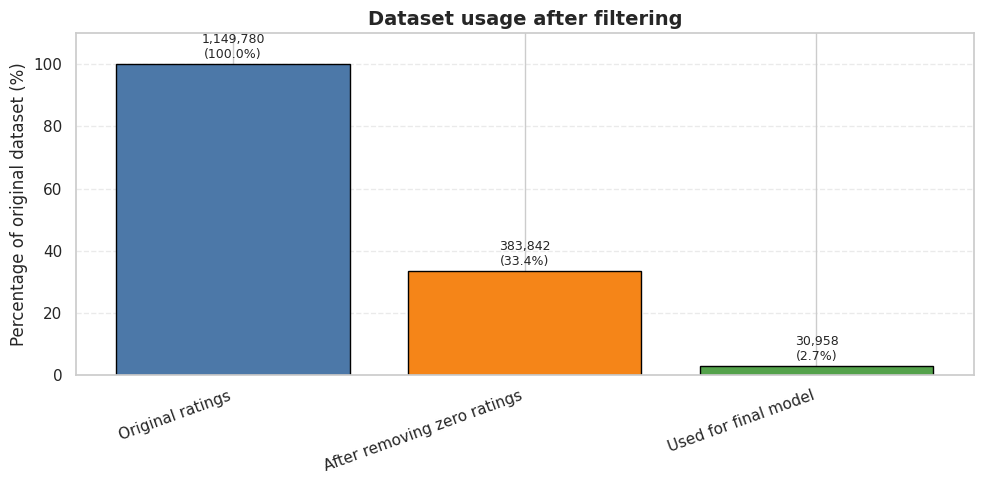

In [92]:
sns.set_theme(style="whitegrid")

stages = ["Original ratings", "After removing zero ratings", "Used for final model"]
counts = [len(ratings), len(df), len(df_filtered)]
percentages = [count / len(ratings) * 100 for count in counts]

plt.figure(figsize=(10, 5))
bar_colors = ["#4C78A8", "#F58518", "#54A24B"]
bars = plt.bar(stages, percentages, color=bar_colors, edgecolor="black", linewidth=1)
plt.title("Dataset usage after filtering", fontsize=14, fontweight="bold")
plt.ylabel("Percentage of original dataset (%)", fontsize=12)
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar, count, pct in zip(bars, counts, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### Export

In [82]:
import pickle

model_path = 'book_recommender_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(item_sim, f)
